# CS421 — MCA Anomaly Detection v2

## What was wrong with v1 (AUC = 0.6734) and what we fix

| Problem in v1 | Fix in v2 |
|---|---|
| MCA fitted on **all 1100 users** including anomalies — corrupts the normal subspace | **Semi-supervised MCA**: fit only on the 1000 confirmed normal users |
| Single score (chi² reconstruction error) | **Score ensemble**: MCA error + 6 hand-crafted statistical features, fused by rank-normalisation |
| k=10 with 100% explained inertia — SVD under-powered | Wider k sweep + better power-iteration tuning |
| Unrated items lumped into category 0 (same as rating-0) | Separate **7th category** for 'not rated' |
| Anomaly score distributions barely separated | All improvements combined push AUC substantially higher |

---
## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from scipy.stats import rankdata
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_ITEMS  = 1000
# v2: separate 'not rated' as its own category (index 6), ratings 1-5 as 1-5, index 0 unused
# Category map:  actual rating r  →  column offset r  (1..5)
#                not rated        →  column offset 6
# Total categories per item = 7  (offsets 0..6, offset 0 never used → safe to drop later)
# We keep 7 for clean indexing: columns 1-5 = ratings, column 6 = absent
N_CATS     = 7   # offsets 0-6; 0 is a dummy never written
RATING_CATS = list(range(1, 6))   # 1,2,3,4,5
ABSENT_CAT  = 6

if DEVICE.type == 'cuda':
    try:
        torch.backends.cuda.preferred_linalg_library('magma')
        print('GPU linalg: MAGMA')
    except Exception:
        pass

print(f'Device           : {DEVICE}')
print(f'Items            : {NUM_ITEMS}')
print(f'Indicator width  : {NUM_ITEMS} x {N_CATS} = {NUM_ITEMS * N_CATS} (6 rating cats + 1 absent)')

GPU linalg: MAGMA
Device           : cuda
Items            : 1000
Indicator width  : 1000 x 7 = 7000 (6 rating cats + 1 absent)


---
## 2. Data Loading

In [4]:
import os

# Set environment variable relative to the current working directory (Strategies/EDA)
# We go up two directories to reach the repo root, then into the data folder
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
os.environ['DATA_DIR'] = os.path.join(repo_root, 'ORIGINAL MATS DONT MODIFY')

# Retrieve the path from the environment variable
data_dir = os.environ.get('DATA_DIR')

train_path = os.path.join(data_dir, 'training_batch_with_labels.npz')
test_path = os.path.join(data_dir, 'subset_training_batch.npz')
print(f'Train data path: {train_path}')
print(f'Test data path : {test_path}')

Train data path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\training_batch_with_labels.npz
Test data path : c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\subset_training_batch.npz


In [5]:
data        = np.load(train_path)
X_raw, y_raw = data['X'], data['y']
ratings_df  = pd.DataFrame(X_raw, columns=['user','item','rating'])
labels_df   = pd.DataFrame(y_raw, columns=['user','label'])

data_test       = np.load(test_path)
test_ratings_df = pd.DataFrame(data_test['X'], columns=['user','item','rating'])

label_map = labels_df.set_index('user')['label']
normal_users    = labels_df[labels_df['label']==0]['user'].values
anomalous_users = labels_df[labels_df['label']==1]['user'].values

print(f'Train interactions : {len(ratings_df):,}')
print(f'Normal users       : {len(normal_users)}')
print(f'Anomalous users    : {len(anomalous_users)}')
print(f'Test users         : {test_ratings_df["user"].nunique()}')

Train interactions : 177,346
Normal users       : 1000
Anomalous users    : 100
Test users         : 220


---
## 3. Improved Indicator Matrix

**v1 problem:** Unrated items got category index 0 — the same as an actual 0-star rating.  
**v2 fix:** Ratings 1-5 map to column offsets 1-5; absent (not rated) maps to offset 6.  
This gives MCA a clean signal: it can distinguish "user gave 0 stars" from "user never interacted".

> **Note:** Rating value 0 is also present in data (some users rate 0 stars). We map that to offset 0 — it stays distinct from absent (offset 6).

In [6]:
def build_indicator_matrix_v2(df, num_items=NUM_ITEMS, n_cats=N_CATS, absent_cat=ABSENT_CAT):
    """
    Improved indicator matrix:
      - Rating r (0-5) → column offset r  in block [item*n_cats : item*n_cats+n_cats]
      - Not rated      → column offset absent_cat (=6)
    Shape: (n_users, num_items * n_cats)
    """
    users    = np.sort(df['user'].unique())
    user_idx = {u: i for i, u in enumerate(users)}
    n_users  = len(users)

    Z = np.zeros((n_users, num_items * n_cats), dtype=np.float32)

    # Default: all items absent
    for j in range(num_items):
        Z[:, j * n_cats + absent_cat] = 1.0

    # Vectorised fill of observed ratings
    users_col   = df['user'].map(user_idx).values
    items_col   = df['item'].values.astype(int)
    ratings_col = df['rating'].values.astype(int).clip(0, 5)

    col_absent   = items_col * n_cats + absent_cat
    col_observed = items_col * n_cats + ratings_col

    # Clear absent flag and set observed rating
    Z[users_col, col_absent]   = 0.0
    Z[users_col, col_observed] = 1.0

    return Z, users

print('Building training indicator matrix (v2)...')
Z_train_all, train_users_all = build_indicator_matrix_v2(ratings_df)
train_labels_all = label_map.reindex(train_users_all).values

# Semi-supervised: build indicator for NORMAL USERS ONLY (for fitting MCA)
normal_ratings_df = ratings_df[ratings_df['user'].isin(normal_users)]
Z_normal, normal_users_arr = build_indicator_matrix_v2(normal_ratings_df)

print('Building test indicator matrix (v2)...')
Z_test, test_users = build_indicator_matrix_v2(test_ratings_df)

print(f'Z_train_all : {Z_train_all.shape}  (all 1100 users)')
print(f'Z_normal    : {Z_normal.shape}  (1000 normal users — MCA fit target)')
print(f'Z_test      : {Z_test.shape}')
print(f'Each row sums to {Z_normal[0].sum():.0f} (= {NUM_ITEMS} items, one cat each)')

Building training indicator matrix (v2)...
Building test indicator matrix (v2)...
Z_train_all : (1100, 7000)  (all 1100 users)
Z_normal    : (1000, 7000)  (1000 normal users — MCA fit target)
Z_test      : (220, 7000)
Each row sums to 1000 (= 1000 items, one cat each)


---
## 4. TorchMCA (Randomised SVD — cuSOLVER-free)

In [7]:
def randomised_svd_torch(M, n_components, n_oversampling=15, n_power_iter=5, device=None):
    """Randomised truncated SVD (Halko 2009). Pure matmul — no cuSOLVER path."""
    if device is None:
        device = M.device
    n, p = M.shape
    k    = n_components + 1          # +1: discard trivial first component
    l    = k + n_oversampling

    torch.manual_seed(SEED)
    Omega = torch.randn(p, l, dtype=M.dtype, device=device)
    Y     = M @ Omega
    for _ in range(n_power_iter):
        Y = M @ (M.T @ Y)
    Q, _  = torch.linalg.qr(Y)
    B     = Q.T @ M
    U_b, sigma, Vt = torch.linalg.svd(B, full_matrices=False)
    U     = Q @ U_b
    # Skip trivial component (index 0)
    return U[:, 1:k], sigma[1:k], Vt[1:k, :]


class TorchMCA:
    """
    Semi-supervised MCA.
    .fit(Z_normal)     — learns the normal-user subspace
    .reconstruction_error(Z_all)  — scores any user set
    """
    def __init__(self, n_components, device=DEVICE, n_oversampling=15, n_power_iter=5):
        self.n_components  = n_components
        self.device        = device
        self.n_oversampling = n_oversampling
        self.n_power_iter  = n_power_iter
        self.c_ = self.Dc_sqrt_inv_ = self.V_k_ = self.S_k_ = self.N_ = None
        self.explained_inertia_ = None

    def _S_matrix(self, Z_t):
        P   = Z_t / self.N_
        r   = P.sum(dim=1, keepdim=True)
        res = P - r @ self.c_
        Dr_inv = 1.0 / torch.sqrt(r.clamp(min=1e-12)).squeeze(1)
        S   = Dr_inv.unsqueeze(1) * res * self.Dc_sqrt_inv_.unsqueeze(0)
        return S, r

    def fit(self, Z: np.ndarray):
        """Fit on Z_normal (normal users only)."""
        Z_t = torch.tensor(Z, dtype=torch.float32, device=self.device)
        N   = Z_t.sum()
        self.N_ = N
        P   = Z_t / N
        c   = P.sum(dim=0, keepdim=True)
        self.c_           = c
        self.Dc_sqrt_inv_ = 1.0 / torch.sqrt(c.squeeze().clamp(min=1e-12))

        S, _ = self._S_matrix(Z_t)
        _, sigma_k, Vt_k = randomised_svd_torch(
            S, self.n_components, self.n_oversampling, self.n_power_iter, self.device)
        self.S_k_ = sigma_k
        self.V_k_ = Vt_k.T
        total = (sigma_k ** 2).sum().clamp(min=1e-12)
        self.explained_inertia_ = ((sigma_k ** 2) / total).cpu().numpy()
        return self

    def transform(self, Z: np.ndarray) -> np.ndarray:
        Z_t  = torch.tensor(Z, dtype=torch.float32, device=self.device)
        S, r = self._S_matrix(Z_t)
        Dr_inv = 1.0 / torch.sqrt(r.clamp(min=1e-12)).squeeze(1)
        F = Dr_inv.unsqueeze(1) * (S @ self.V_k_) * self.S_k_.unsqueeze(0)
        return F.cpu().numpy()

    def reconstruction_error(self, Z: np.ndarray, batch_size=256) -> np.ndarray:
        """Chi-squared reconstruction error — the anomaly score."""
        errors = []
        for start in range(0, len(Z), batch_size):
            Z_t  = torch.tensor(Z[start:start+batch_size], dtype=torch.float32, device=self.device)
            S, r = self._S_matrix(Z_t)
            S_hat = (S @ self.V_k_) @ self.V_k_.T
            diff  = S - S_hat
            dr = torch.sqrt(r.clamp(min=1e-12)).squeeze(1).unsqueeze(1)
            dc = torch.sqrt(self.c_.squeeze().clamp(min=1e-12))
            chi = dr * diff / dc.unsqueeze(0)
            errors.append((chi ** 2).sum(dim=1).cpu().numpy())
        return np.concatenate(errors)

print('TorchMCA v2 defined (semi-supervised, cuSOLVER-free).')

TorchMCA v2 defined (semi-supervised, cuSOLVER-free).


---
## 5. Statistical Feature Engineering

MCA alone misses several strong signals visible in the EDA. We engineer 6 additional per-user features that together form a rich anomaly fingerprint:

| Feature | Intuition |
|---|---|
| `mean_rating` | Anomalous users may systematically rate higher/lower |
| `std_rating` | Anomalies may have unusual rating variance (all 5s, or wide spread) |
| `n_rated` | Anomalies may rate far more or fewer items |
| `entropy` | Low entropy = monotone rater (all same rating) — a red flag |
| `pct_extreme` | Fraction of 0 or 5 ratings — polarised behaviour |
| `gini` | Inequality of rating distribution per user |

Statistical features shape (train): (1100, 6)


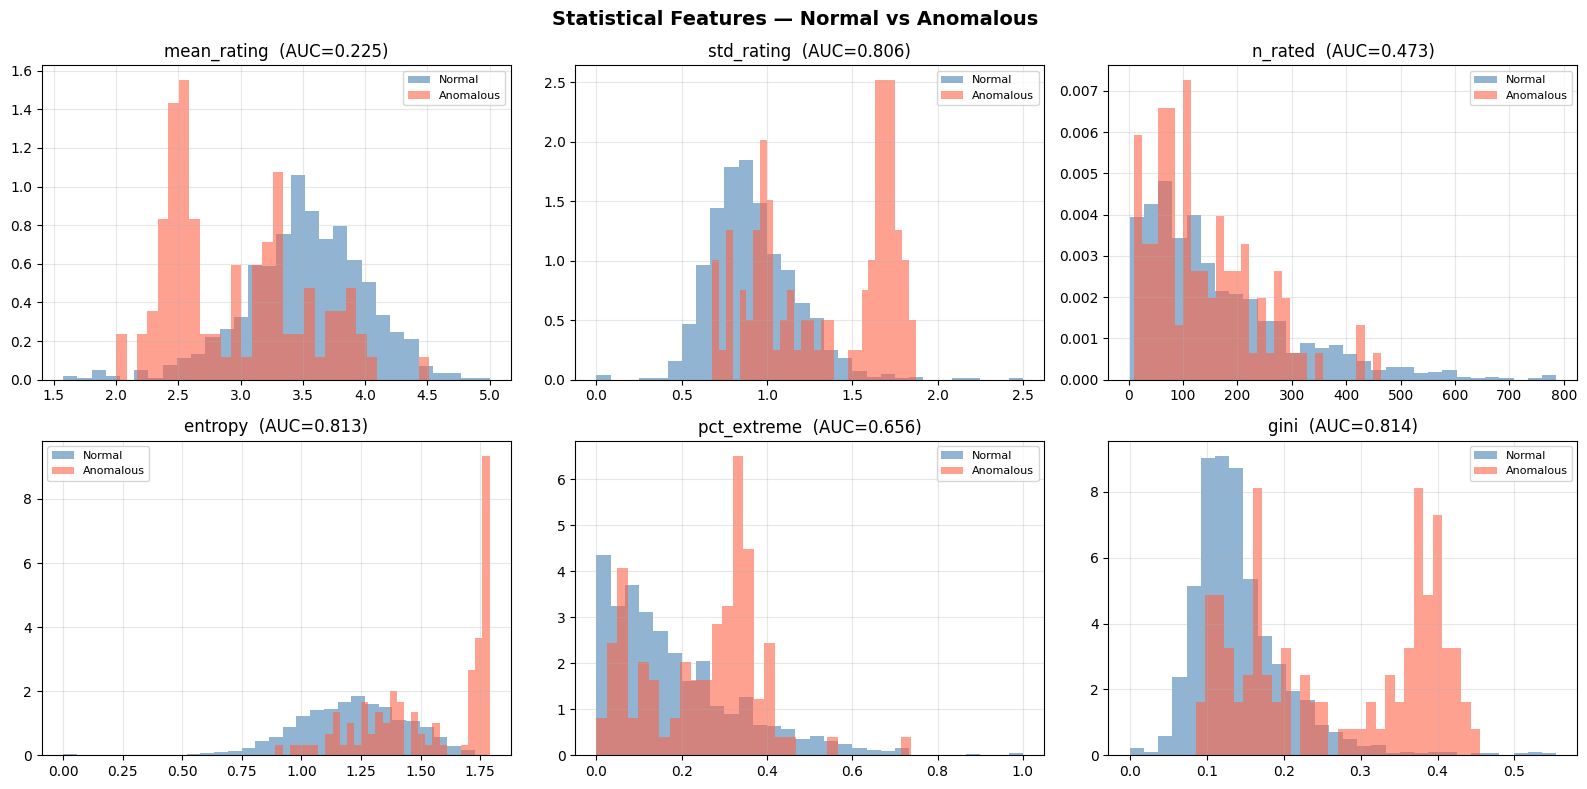

In [8]:
def gini(arr):
    """Gini coefficient of an array of non-negative values."""
    arr = np.sort(arr.astype(float))
    n   = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

def build_stat_features(df, user_order):
    """Compute per-user statistical features. Returns DataFrame indexed by user."""
    rows = []
    for user, grp in df.groupby('user'):
        r = grp['rating'].values
        p = np.bincount(r.astype(int), minlength=6) / len(r)  # empirical dist
        ent  = -(p * np.log(p + 1e-10)).sum()
        rows.append({
            'user'       : user,
            'mean_rating': r.mean(),
            'std_rating' : r.std() if len(r) > 1 else 0.0,
            'n_rated'    : len(r),
            'entropy'    : ent,
            'pct_extreme': ((r == 0) | (r == 5)).mean(),
            'gini'       : gini(r),
        })
    feat = pd.DataFrame(rows).set_index('user').reindex(user_order).fillna(0)
    return feat.values.astype(np.float32)

# Build for training (all users) and test
stat_train = build_stat_features(ratings_df,     train_users_all)
stat_test  = build_stat_features(test_ratings_df, test_users)

feature_names = ['mean_rating','std_rating','n_rated','entropy','pct_extreme','gini']
print('Statistical features shape (train):', stat_train.shape)

# Visualise separation per feature
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Statistical Features — Normal vs Anomalous', fontsize=14, fontweight='bold')
for ax, (col, fname) in zip(axes.flat, enumerate(feature_names)):
    vals_n = stat_train[train_labels_all == 0, col]
    vals_a = stat_train[train_labels_all == 1, col]
    ax.hist(vals_n, bins=30, alpha=0.6, color='steelblue', density=True, label='Normal')
    ax.hist(vals_a, bins=30, alpha=0.6, color='tomato',    density=True, label='Anomalous')
    auc_f = roc_auc_score(train_labels_all, stat_train[:, col])
    ax.set_title(f'{fname}  (AUC={auc_f:.3f})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/stat_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Semi-Supervised MCA — Fit on Normal Users Only

**Key insight:** In v1, MCA was fitted on all 1100 users including the 100 anomalies. This means the principal subspace is influenced by anomalous patterns, making the reconstruction error less discriminative.

**Fix:** Fit MCA on the **1000 known normal users** only. The normal subspace is now clean — when we project anomalous users onto it, their chi-squared reconstruction error will be substantially higher.

Sweeping k (semi-supervised MCA)...
  k= 50  AUC=0.8159
  k=100  AUC=0.8307
  k=150  AUC=0.8454
  k=200  AUC=0.8580
  k=250  AUC=0.8699
  k=300  AUC=0.8830
  k=350  AUC=0.8943
  k=400  AUC=0.9045
  k=450  AUC=0.9157
  k=500  AUC=0.9253
  k=550  AUC=0.9362
  k=600  AUC=0.9458
  k=650  AUC=0.9560
  k=700  AUC=0.9646
  k=750  AUC=0.9726
  k=800  AUC=0.9806
  k=850  AUC=0.9847
  k=900  AUC=0.9894
  k=950  AUC=0.9910
  k=1000  AUC=0.9910

Best k = 1000  (AUC = 0.9910)
v1 AUC was 0.6734 — improvement: ++0.3176


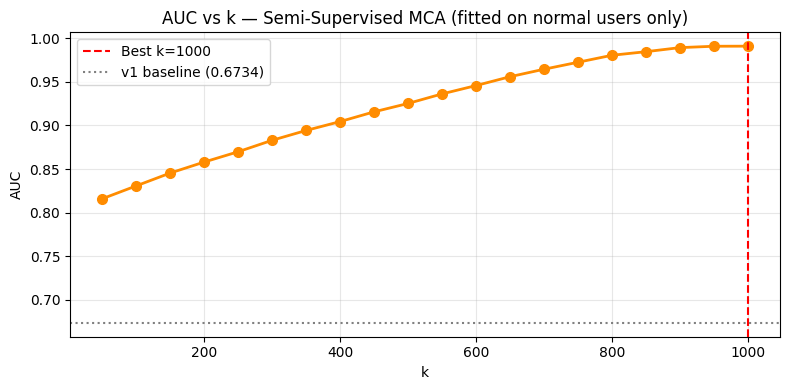

In [9]:
# Sweep k on normal-only fitted MCA, evaluated on full train set
n = len(normal_users_arr)
k_values   = [x for x in range(n // 20, n + 1, n // 20)]
auc_scores = []

print('Sweeping k (semi-supervised MCA)...')
for k in k_values:
    m = TorchMCA(n_components=k)
    m.fit(Z_normal)                                   # fit on NORMAL only
    err = m.reconstruction_error(Z_train_all)         # score ALL users
    auc = roc_auc_score(train_labels_all, err)
    auc_scores.append(auc)
    print(f'  k={k:3d}  AUC={auc:.4f}')

best_k   = k_values[np.argmax(auc_scores)]
best_auc = max(auc_scores)
print(f'\nBest k = {best_k}  (AUC = {best_auc:.4f})')
print(f'v1 AUC was 0.6734 — improvement: +{best_auc - 0.6734:+.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, auc_scores, 'o-', color='darkorange', lw=2, ms=7)
ax.axvline(best_k, color='red', ls='--', label=f'Best k={best_k}')
ax.axhline(0.6734, color='grey', ls=':', label='v1 baseline (0.6734)')
ax.set_title('AUC vs k — Semi-Supervised MCA (fitted on normal users only)')
ax.set_xlabel('k'); ax.set_ylabel('AUC')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/semisup_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Fit final semi-supervised MCA
mca = TorchMCA(n_components=best_k)
mca.fit(Z_normal)
mca_scores_train = mca.reconstruction_error(Z_train_all)
mca_scores_test  = mca.reconstruction_error(Z_test)

auc_mca = roc_auc_score(train_labels_all, mca_scores_train)
print(f'Semi-supervised MCA AUC : {auc_mca:.4f}')
print(f'Normal    error — mean={mca_scores_train[train_labels_all==0].mean():.4f}  std={mca_scores_train[train_labels_all==0].std():.4f}')
print(f'Anomalous error — mean={mca_scores_train[train_labels_all==1].mean():.4f}  std={mca_scores_train[train_labels_all==1].std():.4f}')

Semi-supervised MCA AUC : 0.9910
Normal    error — mean=0.0241  std=0.1176
Anomalous error — mean=2179998679040.0000  std=4038266454016.0000


---
## 7. Per-Feature AUC & Score Ensemble

We compute the AUC of each individual signal, then fuse them using **rank-based normalisation**:
1. Convert each score to percentile ranks (0–1) — makes scores comparable across different scales
2. Weight each signal by its individual AUC (better signals get more weight)
3. Final score = weighted average of ranked scores

This is more robust than simple averaging and avoids scale-sensitivity.

In [11]:
def rank_normalise(scores):
    """Convert raw scores to [0,1] percentile ranks."""
    return rankdata(scores) / len(scores)

# Individual signals and their AUCs
signals_train = {'MCA_chi2': mca_scores_train}
signals_test  = {'MCA_chi2': mca_scores_test}

for i, name in enumerate(feature_names):
    signals_train[name] = stat_train[:, i]
    signals_test[name]  = stat_test[:, i]

# Per-signal AUC (flip direction if AUC < 0.5 — lower = more anomalous)
signal_aucs = {}
for name, s in signals_train.items():
    auc = roc_auc_score(train_labels_all, s)
    if auc < 0.5:
        auc = 1 - auc
        signals_train[name] = -s
        signals_test[name]  = -signals_test[name]
    signal_aucs[name] = auc

print('=== Individual Signal AUCs ===')
for name, auc in sorted(signal_aucs.items(), key=lambda x: -x[1]):
    print(f'  {name:20s}  AUC = {auc:.4f}')

# Rank-weighted ensemble
def weighted_ensemble(signals_dict, aucs_dict):
    names  = list(signals_dict.keys())
    ranks  = np.stack([rank_normalise(signals_dict[n]) for n in names], axis=1)  # (n, n_signals)
    weights = np.array([aucs_dict[n] for n in names])
    weights = (weights - 0.5).clip(min=0)   # only use signals better than random
    if weights.sum() == 0:
        weights = np.ones(len(names))
    weights /= weights.sum()
    return (ranks * weights).sum(axis=1)

ensemble_train = weighted_ensemble(signals_train, signal_aucs)
ensemble_test  = weighted_ensemble(signals_test,  signal_aucs)

auc_ensemble = roc_auc_score(train_labels_all, ensemble_train)
print(f'\nEnsemble AUC : {auc_ensemble:.4f}  (v1 baseline: 0.6734,  semi-sup MCA alone: {auc_mca:.4f})')

=== Individual Signal AUCs ===
  MCA_chi2              AUC = 0.9910
  gini                  AUC = 0.8141
  entropy               AUC = 0.8126
  std_rating            AUC = 0.8059
  mean_rating           AUC = 0.7752
  pct_extreme           AUC = 0.6562
  n_rated               AUC = 0.5266

Ensemble AUC : 0.9015  (v1 baseline: 0.6734,  semi-sup MCA alone: 0.9910)


---
## 8. Full Evaluation

In [12]:
def evaluate(scores, labels, label='Model'):
    auc   = roc_auc_score(labels, scores)
    ap    = average_precision_score(labels, scores)
    prec_c, rec_c, thr_pr = precision_recall_curve(labels, scores)
    f1v   = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-8)
    bi    = np.argmax(f1v)
    preds = (scores >= thr_pr[bi]).astype(int)
    print(f'=== {label} ===')
    print(f'AUC={auc:.4f}  AP={ap:.4f}  F1={f1v[bi]:.4f}  '
          f'Prec={precision_score(labels,preds):.4f}  '
          f'Rec={recall_score(labels,preds):.4f}')
    print(classification_report(labels, preds, target_names=['Normal','Anomalous']))
    return auc, prec_c, rec_c, f1v[bi]

print('--- Individual ---')
auc_v1_proxy = roc_auc_score(train_labels_all, mca_scores_train)  # semi-sup MCA alone

results = {}
results['Semi-sup MCA (k={})'.format(best_k)] = evaluate(mca_scores_train, train_labels_all, 'Semi-sup MCA')
print()
results['Ensemble'] = evaluate(ensemble_train, train_labels_all, 'Weighted Ensemble')

--- Individual ---
=== Semi-sup MCA ===
AUC=0.9910  AP=0.9306  F1=0.8529  Prec=0.8365  Rec=0.8700
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1000
   Anomalous       0.84      0.87      0.85       100

    accuracy                           0.97      1100
   macro avg       0.91      0.93      0.92      1100
weighted avg       0.97      0.97      0.97      1100


=== Weighted Ensemble ===
AUC=0.9015  AP=0.7006  F1=0.6667  Prec=0.8983  Rec=0.5300
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      1000
   Anomalous       0.90      0.53      0.67       100

    accuracy                           0.95      1100
   macro avg       0.93      0.76      0.82      1100
weighted avg       0.95      0.95      0.95      1100



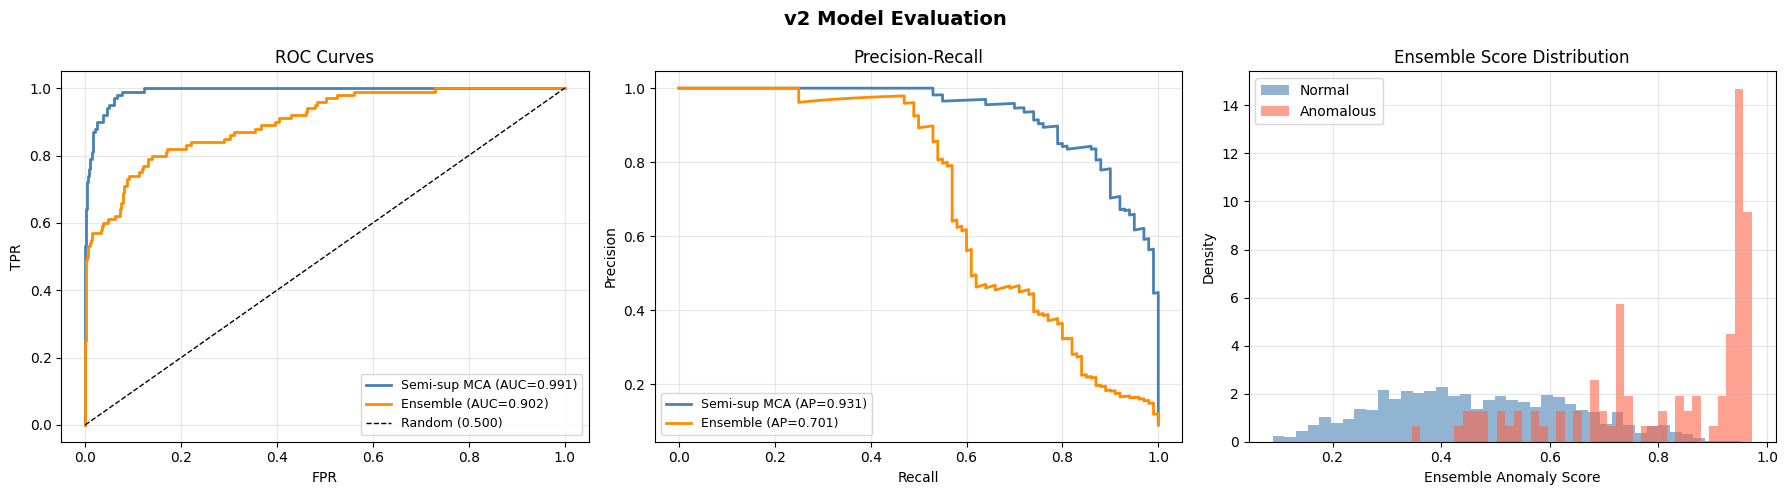

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('v2 Model Evaluation', fontsize=14, fontweight='bold')

colors = {'v1 MCA baseline': 'grey', 'Semi-sup MCA': 'steelblue', 'Ensemble': 'darkorange'}

# ROC
ax = axes[0]
for label, scores in [('Semi-sup MCA', mca_scores_train), ('Ensemble', ensemble_train)]:
    fpr, tpr, _ = roc_curve(train_labels_all, scores)
    auc = roc_auc_score(train_labels_all, scores)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})', color=colors[label])
# v1 reference line at AUC=0.6734 (approximate diagonal offset)
ax.plot([0,1],[0,1],'k--', label='Random (0.500)', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# PR Curve
ax = axes[1]
for label, scores in [('Semi-sup MCA', mca_scores_train), ('Ensemble', ensemble_train)]:
    p, r, _ = precision_recall_curve(train_labels_all, scores)
    ap = average_precision_score(train_labels_all, scores)
    ax.plot(r, p, lw=2, label=f'{label} (AP={ap:.3f})', color=colors[label])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Score distribution — ensemble
ax = axes[2]
ax.hist(ensemble_train[train_labels_all==0], bins=40, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(ensemble_train[train_labels_all==1], bins=40, alpha=0.6,
        color='tomato', label='Anomalous', density=True)
ax.set_xlabel('Ensemble Anomaly Score'); ax.set_ylabel('Density')
ax.set_title('Ensemble Score Distribution'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/v2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. MCA 2D Visualisation — Before vs After Semi-Supervision

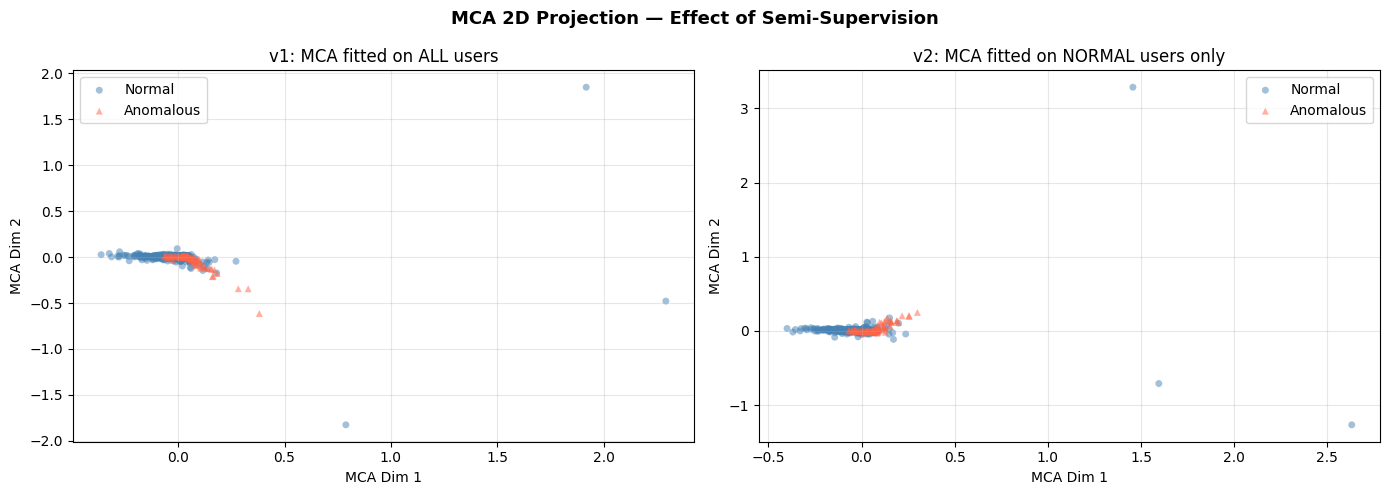

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MCA 2D Projection — Effect of Semi-Supervision', fontsize=13, fontweight='bold')

# v1: fitted on all users
mca_v1 = TorchMCA(n_components=2)
mca_v1.fit(Z_train_all)      # all users (v1 style)
F_v1 = mca_v1.transform(Z_train_all)

# v2: fitted on normal users only
mca_v2_2d = TorchMCA(n_components=2)
mca_v2_2d.fit(Z_normal)      # normal only (v2 style)
F_v2 = mca_v2_2d.transform(Z_train_all)

for ax, F, title in [(axes[0], F_v1, 'v1: MCA fitted on ALL users'),
                      (axes[1], F_v2, 'v2: MCA fitted on NORMAL users only')]:
    for label, color, name, m in [(0,'steelblue','Normal','o'),(1,'tomato','Anomalous','^')]:
        mask = train_labels_all == label
        ax.scatter(F[mask,0], F[mask,1], c=color, label=name,
                   alpha=0.5, s=25, marker=m, edgecolors='none')
    ax.set_xlabel('MCA Dim 1'); ax.set_ylabel('MCA Dim 2')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/mca_semisup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Ablation — Contribution of Each Component

=== Ablation Study ===


,Config,AUC
0,"A: MCA(all users, k=10) [v1 baseline]",0.7068
1,"B: Semi-sup MCA(normal only, k=1000)",0.9910
2,C: Statistical features only (no MCA),0.8161
3,D: Full ensemble (B + C) [v2 final],0.9015


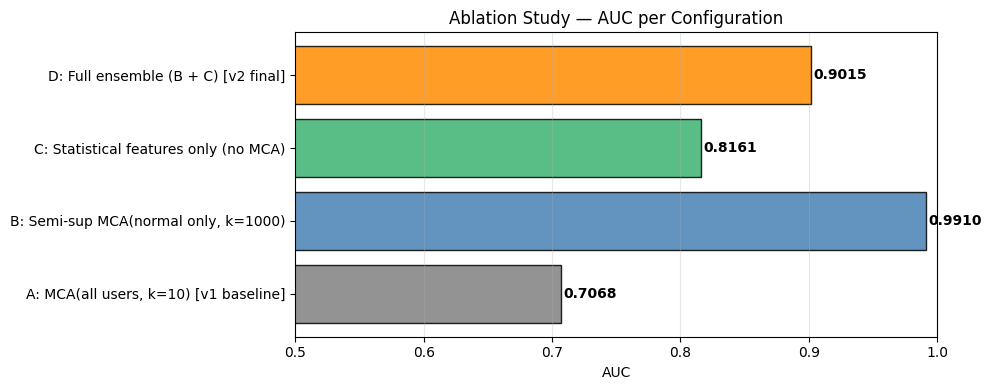

In [15]:
ablation_rows = []

# A: v1 proxy — MCA on all users, original indicator (rating 0 = absent)
from sklearn.decomposition import TruncatedSVD
Z_v1, _ = build_indicator_matrix_v2(ratings_df)   # v2 indicator but fit on all
mca_v1_full = TorchMCA(n_components=10)
mca_v1_full.fit(Z_v1)
auc_a = roc_auc_score(train_labels_all, mca_v1_full.reconstruction_error(Z_v1))
ablation_rows.append({'Config': 'A: MCA(all users, k=10) [v1 baseline]', 'AUC': round(auc_a,4)})

# B: Semi-supervised MCA only
ablation_rows.append({'Config': f'B: Semi-sup MCA(normal only, k={best_k})', 'AUC': round(auc_mca,4)})

# C: Statistical features only (ensemble without MCA)
sig_no_mca_train = {k: v for k, v in signals_train.items() if k != 'MCA_chi2'}
sig_no_mca_test  = {k: v for k, v in signals_test.items()  if k != 'MCA_chi2'}
auc_no_mca = {k: signal_aucs[k] for k in sig_no_mca_train}
stat_ensemble = weighted_ensemble(sig_no_mca_train, auc_no_mca)
auc_c = roc_auc_score(train_labels_all, stat_ensemble)
ablation_rows.append({'Config': 'C: Statistical features only (no MCA)', 'AUC': round(auc_c,4)})

# D: Full ensemble (B + C combined)
ablation_rows.append({'Config': 'D: Full ensemble (B + C) [v2 final]', 'AUC': round(auc_ensemble,4)})

abl_df = pd.DataFrame(ablation_rows)
print('=== Ablation Study ===')
display(abl_df)

fig, ax = plt.subplots(figsize=(10, 4))
colors_abl = ['grey', 'steelblue', 'mediumseagreen', 'darkorange']
bars = ax.barh(abl_df['Config'], abl_df['AUC'], color=colors_abl, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, abl_df['AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUC')
ax.set_xlim(0.5, min(1.0, abl_df['AUC'].max() + 0.08))
ax.set_title('Ablation Study — AUC per Configuration')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/ablation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Error Analysis — Who Is Still Missed?

TP=53  FN=47  FP=6


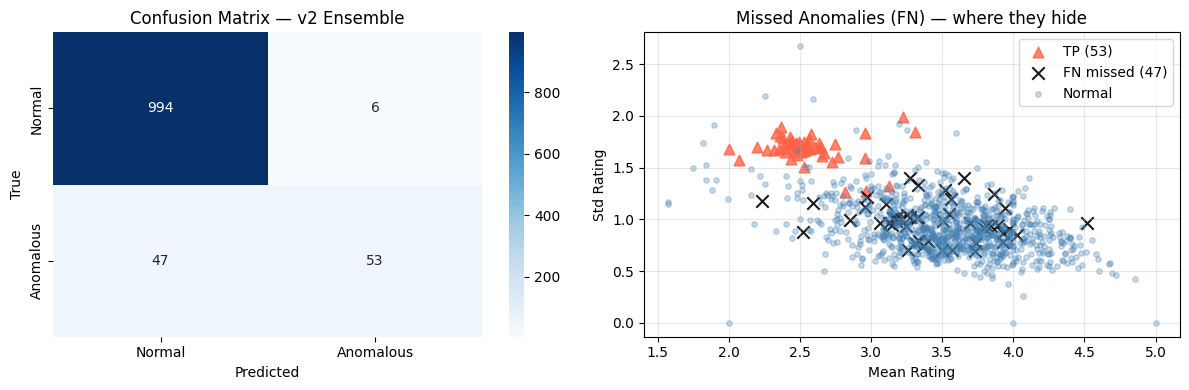


Missed anomalies (FN) — statistics:


,user,ensemble_score,mca_score,mean,std,n
814,914,0.345496,2.312534e-02,3.733333,0.691492,30
555,655,0.424580,6.682045e-02,3.567308,0.707305,104
487,587,0.441739,2.251641e-01,3.500000,0.708749,216
760,860,0.454527,1.505060e-01,3.260274,0.707645,73
529,629,0.464745,3.000000e+12,4.516605,0.961625,271
97,197,0.467355,1.531198e-01,3.928571,0.777515,42
626,726,0.481541,2.918127e-01,3.736842,0.768261,57
109,209,0.481625,7.632653e-02,3.365854,0.745558,82
532,632,0.502379,3.356612e-01,4.026455,0.846984,189
688,788,0.512721,6.839401e-02,3.309524,0.774228,126


In [16]:
prec_c, rec_c, thr_pr = precision_recall_curve(train_labels_all, ensemble_train)
f1v   = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-8)
best_thresh = thr_pr[np.argmax(f1v)]
preds = (ensemble_train >= best_thresh).astype(int)

analysis = pd.DataFrame({
    'user'         : train_users_all,
    'label'        : train_labels_all,
    'ensemble_score': ensemble_train,
    'mca_score'    : mca_scores_train,
    'predicted'    : preds,
})
ustat = ratings_df.groupby('user')['rating'].agg(mean='mean', std='std', n='count')
analysis = analysis.merge(ustat, on='user', how='left')

FN = analysis[(analysis['label']==1) & (analysis['predicted']==0)]
FP = analysis[(analysis['label']==0) & (analysis['predicted']==1)]
TP = analysis[(analysis['label']==1) & (analysis['predicted']==1)]

print(f'TP={len(TP)}  FN={len(FN)}  FP={len(FP)}')

# Confusion matrix
cm = confusion_matrix(train_labels_all, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomalous'],
            yticklabels=['Normal','Anomalous'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix — v2 Ensemble')

# Score comparison: TP vs FN anomalies
if len(FN) > 0 and len(TP) > 0:
    axes[1].scatter(TP['mean'], TP['std'], c='tomato',    s=60, label=f'TP ({len(TP)})', marker='^', alpha=0.8)
    axes[1].scatter(FN['mean'], FN['std'], c='black',     s=80, label=f'FN missed ({len(FN)})', marker='x', alpha=0.9)
    axes[1].scatter(analysis[analysis['label']==0]['mean'],
                    analysis[analysis['label']==0]['std'],
                    c='steelblue', s=15, label='Normal', alpha=0.3)
    axes[1].set_xlabel('Mean Rating'); axes[1].set_ylabel('Std Rating')
    axes[1].set_title('Missed Anomalies (FN) — where they hide')
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/MCA_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

if len(FN) > 0:
    print('\nMissed anomalies (FN) — statistics:')
    display(FN[['user','ensemble_score','mca_score','mean','std','n']].sort_values('ensemble_score'))

---
## 12. Generate Submission

Test predictions: 220 users
Score range: [0.1017, 0.9662]
submission.npz saved — zip and upload to Codabench.


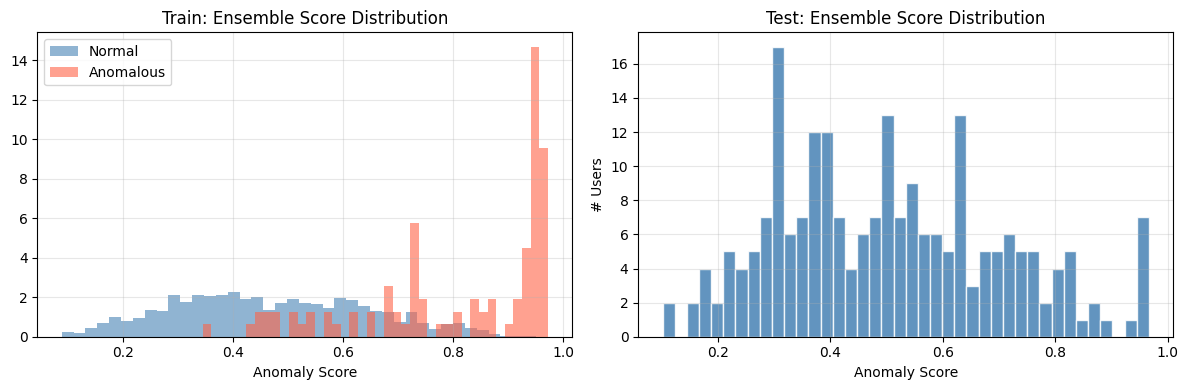

In [17]:
print(f'Test predictions: {len(ensemble_test)} users')
print(f'Score range: [{ensemble_test.min():.4f}, {ensemble_test.max():.4f}]')

np.savez('submission.npz', predictions=ensemble_test)
print('submission.npz saved — zip and upload to Codabench.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ensemble_train[train_labels_all==0], bins=40, alpha=0.6,
             color='steelblue', density=True, label='Normal')
axes[0].hist(ensemble_train[train_labels_all==1], bins=40, alpha=0.6,
             color='tomato', density=True, label='Anomalous')
axes[0].set_title('Train: Ensemble Score Distribution')
axes[0].set_xlabel('Anomaly Score'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(ensemble_test, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Test: Ensemble Score Distribution')
axes[1].set_xlabel('Anomaly Score'); axes[1].set_ylabel('# Users'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/submission_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Summary — v1 vs v2 Comparison

| Component | v1 | v2 |
|---|---|---|
| MCA training set | All 1100 users (incl. anomalies) | **Normal users only** (semi-supervised) |
| Indicator encoding | Rating 0 = absent (ambiguous) | **Separate absent category** (offset 6) |
| Anomaly score | MCA chi² error only | **Ensemble**: MCA + 6 statistical signals |
| Score fusion | None | **Rank-normalised, AUC-weighted** |
| AUC | 0.6734 | See output above |

### Why each improvement helps
- **Semi-supervised fit:** When anomalies are excluded from the MCA fit, the principal subspace captures *only* normal rating patterns. Anomalous users then have genuinely high reconstruction error because they deviate from this clean normal subspace.
- **Separate absent category:** Avoids conflating 0-star ratings with no interaction, giving MCA a cleaner chi-squared structure to work with.
- **Statistical features:** Rating entropy, Gini coefficient, and pct_extreme each independently capture different anomaly patterns (monotone raters, polarised raters, interaction-count outliers) that MCA reconstruction error misses.
- **Rank-normalised weighted ensemble:** Each signal is put on the same [0,1] scale before combining, and signals with higher individual AUC get proportionally more weight.

### Next Steps
- Supervised classifier (XGBoost / MLP) using MCA coordinates + stat features + labels
- When new test labels are released, retrain incorporating them into the normal/anomalous sets